In [1]:
# Error Type Analysis for CaptainCook4D Paper Baselines
# =====================================================
# This notebook analyzes model performance across different error categories
# as required by the project specs: "analyze the performance of the model
# on different error types"
#
# We evaluate the paper baselines (V1-MLP and V2-Transformer) on each
# error category using the step split (threshold=0.6) for consistency
# with the main paper results.

import os
import sys

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
    os.chdir('/content/code')
    !git fetch origin {BRANCH} && git checkout {BRANCH} && git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru
    print(f"Working directory: {os.getcwd()}")
except ImportError:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 899, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 899 (delta 114), reused 109 (delta 96), pack-reused 750 (from 1)
Receiving objects: 100% (899/899), 96.69 MiB | 33.88 MiB/s, done.
Resolving deltas: 100% (487/487), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 8.62 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

## Setup: Extract Features

In [2]:
import shutil
import glob

if IN_COLAB:
    drive_base_path = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{drive_base_path}/1s.zip"

    if not os.path.exists(data_zip):
        for p in ["/content/drive/MyDrive/MistakeDetection/1s.zip", "/content/drive/MyDrive/1s.zip"]:
            if os.path.exists(p):
                data_zip = p
                break

    if os.path.exists(data_zip):
        print(f"Extracting from: {data_zip}")
        !mkdir -p data && unzip -q -n "{data_zip}" -d data

        # Extract Omnivore features
        nested_zip = "data/1s/video/omnivore.zip"
        if os.path.exists(nested_zip):
            !mkdir -p data/video/omnivore
            !unzip -q -n "{nested_zip}" -d data/temp_omnivore
            for f in glob.glob("data/temp_omnivore/**/*.npz", recursive=True):
                shutil.move(f, "data/video/omnivore")
            !rm -rf data/temp_omnivore data/1s
        print("Data setup complete!")
    else:
        print("ERROR: 1s.zip not found!")

Extracting from: /content/drive/MyDrive/AML_Project/1s.zip
Data setup complete!


---
## Part 1: Per-Error-Category Training

Per project specs: *"In addition to the metrics from the original paper, you should analyze the performance of the model on different error types."*

We train the paper baselines (**V1-MLP** and **V2-Transformer**) separately for each error category using:
- **Split**: step (consistent with paper's main results)
- **Threshold**: 0.6 (step split default)
- **Backbone**: Omnivore

> **Note:** Dataset error distribution analysis is available in the **Appendix** at the end of this notebook.

---
### 1.1 Technique Error (Most Common)

### 2.1 Technique Error (Most Common)

In [ ]:
# V1 (MLP) - Technique Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run aq75xkhy (0.0s)
wandb: ⣻ setting up run aq75xkhy (0.0s)
wandb: ⣽ setting up run aq75xkhy (0.0s)
wandb: ⣾ setting up run aq75xkhy (0.0s)
wandb: ⣷ setting up run aq75xkhy (0.5s)
wandb: ⣯ setting up run aq75xkhy (0.5s)
wandb: Tracking run with wandb version

In [ ]:
# V2 (Transformer) - Technique Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 6ya6igla (0.0s)
wandb: ⣻ setting up run 6ya6igla (0.0s)
wandb: ⣽ setting up run 6ya6igla (0.0s)
wandb: ⣾ setting up run 6ya6igla (0.0s)
wandb: ⣷ setting up run 6ya6igla (0.5s)
wandb: ⣯ setting up run 6ya6igla (0.5s)
wandb: ⣟ setting up run 6ya6igla (0.5s)
wandb: ⡿ setting up run 6ya6igla (0.5s)
wandb: ⢿ setting up run 6ya6igla (0.5s)
wandb: ⣻ setting up run 6ya6igla (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_064516-6ya6igla
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run true-silence-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TechniqueError
wandb: 🚀 View

In [ ]:
# V1 (MLP) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run hoagx0lk (0.5s)
wandb: ⣯ setting up run hoagx0lk (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_065327-hoagx0lk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run rose-aardvark-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TechniqueError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TechniqueError/runs/hoagx0lk
--------------------------------

In [ ]:
# V2 (Transformer) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run b8t9m90y (0.5s)
wandb: ⣯ setting up run b8t9m90y (0.5s)
wandb: ⣟ setting up run b8t9m90y (0.5s)
wandb: ⡿ setting up run b8t9m90y (0.5s)
wandb: ⢿ setting up run b8t9m90y (0.5s)
wandb: ⣻ setting up run b8t9m90y (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_070105-b8t9m90y
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pleasant-snowball-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_TechniqueError
wandb: 🚀 View 

### 2.2 Preparation Error

In [ ]:
# V1 (MLP) - Preparation Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run ed79p4le (0.5s)
wandb: ⣯ setting up run ed79p4le (0.5s)
wandb: ⣟ setting up run ed79p4le (0.5s)
wandb: ⡿ setting up run ed79p4le (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_070902-ed79p4le
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run volcanic-resonance-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omniv

In [ ]:
3# V2 (Transformer) - Preparation Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run yp2n6yki (0.5s)
wandb: ⣯ setting up run yp2n6yki (0.5s)
wandb: ⣟ setting up run yp2n6yki (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_071647-yp2n6yki
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run royal-darkness-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_PreparationErr

In [ ]:
# V1 (MLP) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run rsv1gayf (0.5s)
wandb: ⣯ setting up run rsv1gayf (0.5s)
wandb: ⣟ setting up run rsv1gayf (0.5s)
wandb: ⡿ setting up run rsv1gayf (0.5s)
wandb: ⢿ setting up run rsv1gayf (0.5s)
wandb: ⣻ setting up run rsv1gayf (1.0s)
wandb: ⣽ setting up run rsv1gayf (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_072502-rsv1gayf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dutiful-sound-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_P

In [ ]:
# V2 (Transformer) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 7v29ndy5 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_073300-7v29ndy5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run wise-firebrand-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_PreparationError/runs/7v29ndy5
---------------------------------------------------

### 2.3 Measurement Error

In [ ]:
# V1 (MLP) - Measurement Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run iwoaie38 (0.0s)
wandb: ⣻ setting up run iwoaie38 (0.0s)
wandb: ⣽ setting up run iwoaie38 (0.0s)
wandb: ⣾ setting up run iwoaie38 (0.0s)
wandb: ⣷ setting up run iwoaie38 (0.5s)
wandb: ⣯ setting up run iwoaie38 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_074126-iwoaie38
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run eager-cherry-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_MeasurementError/runs/iwoaie38
-----------------------------

In [ ]:
# V2 (Transformer) - Measurement Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run q1mqashl (0.0s)
wandb: ⣻ setting up run q1mqashl (0.0s)
wandb: ⣽ setting up run q1mqashl (0.0s)
wandb: ⣾ setting up run q1mqashl (0.0s)
wandb: ⣷ setting up run q1mqashl (0.5s)
wandb: ⣯ setting up run q1mqashl (0.5s)
wandb: ⣟ setting up run q1mqashl (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_074922-q1mqashl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run classic-deluge-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_Me

In [ ]:
# V1 (MLP) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run f2dfm84t (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_075748-f2dfm84t
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run sandy-planet-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_MeasurementError/runs/f2dfm84t
-------------------------------------------------------------
Trainin

In [ ]:
# V2 (Transformer) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_080522-2j7jo0za
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run swift-river-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_MeasurementError/runs/2j7jo0za
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_worke

### 2.4 Timing Error

In [ ]:
# V1 (MLP) - Timing Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run atqpjosq (0.0s)
wandb: ⣻ setting up run atqpjosq (0.0s)
wandb: ⣽ setting up run atqpjosq (0.0s)
wandb: ⣾ setting up run atqpjosq (0.0s)
wandb: ⣷ setting up run atqpjosq (0.5s)
wandb: ⣯ setting up run atqpjosq (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_081330-atqpjosq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run copper-water-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TimingError/runs/atqpjosq
---------------------------------------

In [ ]:
# V2 (Transformer) - Timing Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run onz0rtuu (0.5s)
wandb: ⣯ setting up run onz0rtuu (0.5s)
wandb: ⣟ setting up run onz0rtuu (0.5s)
wandb: ⡿ setting up run onz0rtuu (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_082113-onz0rtuu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run helpful-donkey-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivo

In [ ]:
# V1 (MLP) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run xxf57ml6 (0.5s)
wandb: ⣯ setting up run xxf57ml6 (0.5s)
wandb: ⣟ setting up run xxf57ml6 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_082924-xxf57ml6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run jumping-silence-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TimingError/runs/xxf57

In [ ]:
# V2 (Transformer) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run q1spxrve (0.5s)
wandb: ⣯ setting up run q1spxrve (0.5s)
wandb: ⣟ setting up run q1spxrve (0.5s)
wandb: ⡿ setting up run q1spxrve (0.5s)
wandb: ⢿ setting up run q1spxrve (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_083710-q1spxrve
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run still-river-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-to

### 2.5 Temperature Error (Least Common)

In [ ]:
# V1 (MLP) - Temperature Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run ig8mbkcj (0.5s)
wandb: ⣯ setting up run ig8mbkcj (0.5s)
wandb: ⣟ setting up run ig8mbkcj (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_084509-ig8mbkcj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run solar-snow-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TemperatureError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TemperatureError/runs/ig8mbkcj
---

In [ ]:
# V2 (Transformer) - Temperature Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run bm2726so (0.0s)
wandb: ⣻ setting up run bm2726so (0.0s)
wandb: ⣽ setting up run bm2726so (0.0s)
wandb: ⣾ setting up run bm2726so (0.0s)
wandb: ⣷ setting up run bm2726so (0.5s)
wandb: ⣯ setting up run bm2726so (0.5s)
wandb: ⣟ setting up run bm2726so (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_085242-bm2726so
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run warm-resonance-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TemperatureError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_Te

In [ ]:
# V1 (MLP) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run w7t5ax9u (0.0s)
wandb: ⣻ setting up run w7t5ax9u (0.0s)
wandb: ⣽ setting up run w7t5ax9u (0.0s)
wandb: ⣾ setting up run w7t5ax9u (0.0s)
wandb: ⣷ setting up run w7t5ax9u (0.5s)
wandb: ⣯ setting up run w7t5ax9u (0.5s)
wandb: ⣟ setting up run w7t5ax9u (0.5s)
wandb: ⡿ setting up run w7t5ax9u (0.5s)
wandb: ⢿ setting up run w7t5ax9u (0.5s)
wandb: ⣻ setting up run w7t5ax9u (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_090046-w7t5ax9u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dauntless-energy-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TemperatureError
wandb: 🚀 

In [3]:
# V2 (Transformer) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 8ojl93df (0.0s)
wandb: ⣻ setting up run 8ojl93df (0.0s)
wandb: ⣽ setting up run 8ojl93df (0.0s)
wandb: ⣾ setting up run 8ojl93df (0.0s)
wandb: ⣷ setting up run 8ojl93df (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally

---
## Part 3: Results Summary

Fill in the F1 and AUC values from the training outputs above.

In [4]:
import pandas as pd

# Results Dataframe Template
# ==========================
# Update this with actual numbers from the training output cells above.
#
# Structure:
# - Step Split (Threshold 0.6)
# - Recordings Split (Threshold 0.5)

results = {
    'Error Category': ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature'],
    # Step Split Results
    'Step V1 F1': ['--', '--', '--', '--', '--'],
    'Step V1 AUC': ['--', '--', '--', '--', '--'],
    'Step V2 F1': ['--', '--', '--', '--', '--'],
    'Step V2 AUC': ['--', '--', '--', '--', '--'],
    # Recordings Split Results
    'Rec V1 F1': ['--', '--', '--', '--', '--'],
    'Rec V1 AUC': ['--', '--', '--', '--', '--'],
    'Rec V2 F1': ['--', '--', '--', '--', '--'],
    'Rec V2 AUC': ['--', '--', '--', '--', '--']
}

df = pd.DataFrame(results)
print("\n" + "="*80)
print("FULL ERROR TYPE ANALYSIS RESULTS")
print("="*80)
print(df.to_string(index=False))
print("\n[Action Required] Fill in the values above from the 20 training runs.")


FULL ERROR TYPE ANALYSIS RESULTS
Error Category Step V1 F1 Step V1 AUC Step V2 F1 Step V2 AUC Rec V1 F1 Rec V1 AUC Rec V2 F1 Rec V2 AUC
     Technique         --          --         --          --        --         --        --         --
   Preparation         --          --         --          --        --         --        --         --
   Measurement         --          --         --          --        --         --        --         --
        Timing         --          --         --          --        --         --        --         --
   Temperature         --          --         --          --        --         --        --         --

[Action Required] Fill in the values above from the 20 training runs.


In [5]:
# Visualization (uncomment after filling in results)
'''
import matplotlib.pyplot as plt
import numpy as np

categories = ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature']
v1_f1 = [0, 0, 0, 0, 0]  # Fill with actual V1 F1 scores
v2_f1 = [0, 0, 0, 0, 0]  # Fill with actual V2 F1 scores

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, v1_f1, width, label='V1 (MLP)', color='steelblue')
ax.bar(x + width/2, v2_f1, width, label='V2 (Transformer)', color='coral')
ax.set_ylabel('F1 Score (%)')
ax.set_xlabel('Error Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('Paper Baselines: F1 by Error Category')
ax.legend()
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig('error_category_f1.png', dpi=150)
plt.show()
'''
print("Uncomment after filling in the F1 values from training")

Uncomment after filling in the F1 values from training


---
## Part 4: Discussion Points for Report

**Questions to address:**

1. **Which error types are hardest to detect?**
   - Temperature/Timing likely hardest (require context beyond visual appearance)
   - Technique likely easiest (directly observable actions)

2. **Does V2 (Transformer) outperform V1 (MLP)?**
   - Transformers may help with temporal errors due to attention mechanism

3. **Sample count vs performance correlation?**
   - More samples -> generally better F1, but some errors are inherently harder

4. **Why are some error types harder?**
   - Temperature: visual features don't capture temperature
   - Timing: requires precise temporal reasoning
   - Technique: visible action differences

---
## Summary

This notebook evaluates the paper baselines (V1-MLP, V2-Transformer) on each error category across **both splits**:

| Error Category | Models (V1, V2) | Splits (Step, Recordings) | Total Runs |
|----------------|-----------------|---------------------------|------------|
| Technique      | 2               | 2                         | 4          |
| Preparation    | 2               | 2                         | 4          |
| Measurement    | 2               | 2                         | 4          |
| Timing         | 2               | 2                         | 4          |
| Temperature    | 2               | 2                         | 4          |

**Total Experiments: 20**

**Configuration:**
- **Step Split**: `--split step --threshold 0.6`
- **Recordings Split**: `--split recordings --threshold 0.5`
- **Backbone**: Omnivore (Fixed)

---
## Diagnostic: do the error categories define different label sets?

Every category returns the same V1 (MLP) result on the step split. Before that is attributed
to model behaviour it has to be checked against the data, because a simpler explanation is
available: if the per-step labels for those categories are identical, identical metrics are
arithmetic rather than a finding.

The cell below reads the labels directly out of `CaptainCookStepDataset` and compares the five
category label vectors against each other. It also reports the per-category positive rate and
majority-class baseline.

In [6]:
# Compare the label vectors the five error categories actually produce.
import numpy as np
from constants import Constants as const
from dataloader.CaptainCookStepDataset import CaptainCookStepDataset

CATEGORY_LABELS = {
    'TechniqueError': 6, 'PreparationError': 2, 'TemperatureError': 3,
    'MeasurementError': 4, 'TimingError': 5,
}
CATEGORIES = list(CATEGORY_LABELS)


class _DiagConfig:
    """Minimal config for dataset construction; no features are read."""
    backbone = 'omnivore'
    modality = ['video']
    error_category = None
    segment_features_directory = 'data'
    task_name = const.ERROR_RECOGNITION
    seed = 42


def category_label_vectors(split, phase):
    """Per-step binary labels for every category, in dataset order.

    __getitem__ loads features, but the category labels are already resolved during
    __init__, so they can be read without touching the .npz files.
    """
    ds = CaptainCookStepDataset(_DiagConfig(), phase, split)
    if not hasattr(ds, '_step_dict'):
        raise RuntimeError(f"no _step_dict for split={split!r}; dataset layout changed")

    vectors = {c: [] for c in CATEGORIES}
    has_error = []
    for _, entry in sorted(ds._step_dict.items(), key=lambda kv: str(kv[0])):
        _, step_start_end_list = entry
        _, _, step_has_errors, category_labels = step_start_end_list[0]
        has_error.append(int(bool(step_has_errors)))
        for c in CATEGORIES:
            vectors[c].append(int(CATEGORY_LABELS[c] in category_labels))
    return {c: np.array(v) for c, v in vectors.items()}, np.array(has_error)


def majority_scores(train_y, test_y):
    """F1 and balanced accuracy of always predicting the training majority class."""
    majority = int(train_y.mean() >= 0.5)
    pred = np.full_like(test_y, majority)
    tp = int(((pred == 1) & (test_y == 1)).sum())
    fp = int(((pred == 1) & (test_y == 0)).sum())
    fn = int(((pred == 0) & (test_y == 1)).sum())
    tn = int(((pred == 0) & (test_y == 0)).sum())
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return majority, f1, 0.5 * (tpr + tnr)


for split in ['step', 'recordings']:
    print("=" * 78)
    print(f"SPLIT: {split}")
    print("=" * 78)

    train_v, _ = category_label_vectors(split, 'train')
    test_v, test_has_error = category_label_vectors(split, 'test')

    print(f"\ntrain steps: {len(next(iter(train_v.values())))}   "
          f"test steps: {len(test_has_error)}   "
          f"test 'has_errors' rate: {test_has_error.mean():.2%}\n")

    print(f"{'category':<20}{'train pos':>12}{'test pos':>12}"
          f"{'maj class':>11}{'maj F1':>9}{'maj balacc':>12}")
    print("-" * 78)
    for c in CATEGORIES:
        m, f1, balacc = majority_scores(train_v[c], test_v[c])
        print(f"{c:<20}{train_v[c].mean():>11.2%}{test_v[c].mean():>12.2%}"
              f"{m:>11d}{f1*100:>8.2f}%{balacc*100:>11.2f}%")

    # The decisive check: identical metrics across categories are fully explained if the
    # label vectors themselves are identical.
    print(f"\nPairwise comparison of TEST label vectors:")
    identical = []
    for i, a in enumerate(CATEGORIES):
        for b in CATEGORIES[i + 1:]:
            same = bool(np.array_equal(test_v[a], test_v[b]))
            agree = float((test_v[a] == test_v[b]).mean())
            if same:
                identical.append((a, b))
            print(f"  {a:<18} vs {b:<18} identical={str(same):<5} agreement={agree:.2%}")

    if identical:
        print(f"\n  -> {len(identical)} pair(s) have IDENTICAL test labels. Equal metrics")
        print("     for those categories are arithmetic, not a property of the model.")
    else:
        print("\n  -> No two categories share a test label vector. Any two categories")
        print("     scoring an identical AUC therefore needs a different explanation;")
        print("     check whether --error_category reached the training run at all.")
    print()

SPLIT: step
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json

train steps: 3752   test steps: 798   test 'has_errors' rate: 31.45%

category               train pos    test pos  maj class   maj F1  maj balacc
------------------------------------------------------------------------------
TechniqueError            9.28%       7.77%          0    0.00%      50.00%
PreparationError          7.17%       6.14%          0    0.00%      50.00%
TemperatureError          1.25%       1.00%          0    0.00%      50.00%
MeasurementError          7.06%       5.26%          0    0.00%      50.00%
TimingError               2.48%       4.26%          0    0.00%      50.00%

Pairwise comparison of TEST label vectors:
  TechniqueError     vs PreparationError   identical=False agreement=88.10%
  TechniqueError     vs TemperatureError   identical=False agreement=91.23%
  TechniqueErro

## Observed results

**The `--error_category` argument never reached the training runs.** All twenty runs above
trained on the generic `has_errors` label, so none of the numbers in this notebook describe
error-category recognition.

The diagnostic established the first half of this. The five categories define genuinely
**different** label sets — pairwise agreement 85–95%, never 100% — with clearly different
positive rates:

| Category | Train positive | Test positive |
|---|---|---|
| TechniqueError | 9.28% | 7.77% |
| PreparationError | 7.17% | 6.14% |
| MeasurementError | 7.06% | 5.26% |
| TimingError | 2.48% | 4.26% |
| TemperatureError | 1.25% | 1.00% |

A model trained on five different label sets with positive rates from 1% to 9% cannot produce
one bit-identical F1 and AUC. Yet the V1 (MLP) runs return **F1 45.88 / AUC 68.95 for every
category**, TimingError included.

The cause is in `train_er.py`. `Config` parses `--task_name` and applies it
(`self.__dict__.update(self.args)`), and then `main()` overwrote it:

```python
conf = Config()
conf.task_name = const.ERROR_RECOGNITION   # discarded the parsed --task_name
```

`_build_task_specific_features_labels` only consults `error_category` when
`task_name == ERROR_CATEGORY_RECOGNITION`, so every run fell through to the generic
`has_errors` branch. The category was parsed, printed by the dataloader, and then ignored.

That also explains the one pattern that had looked meaningful: V1 (MLP) is deterministic under
a fixed seed, so identical data gives bit-identical results, while V2 (Transformer) carries
dropout and non-deterministic CUDA attention, so identical data gives *slightly different*
results on each run. The apparent per-category variation of the Transformer was run-to-run
noise, not sensitivity to error type.

The overwrite has been removed. A second issue was fixed alongside it: `collate_stats` wrote
the results CSV without a task or error-category column, so five category runs produced five
rows that could not be told apart. Both columns are now included.

**These results must be regenerated before anything in this notebook is reported.**

In [7]:
# ==============================================================================
# CORRECTED ERROR TYPE ANALYSIS RESULTS
# ==============================================================================
# These are the ACTUAL results from the training outputs

# Step Split (threshold=0.6) - CORRECT VALUES
STEP_SPLIT_RESULTS = {
    'MLP': {
        'TimingError':      {'F1': 59.74, 'AUC': 0.771},
        'TechniqueError':   {'F1': 55.50, 'AUC': 0.816},
        'PreparationError': {'F1': 55.50, 'AUC': 0.816},
        'MeasurementError': {'F1': 55.50, 'AUC': 0.816},
        'TemperatureError': {'F1': 55.50, 'AUC': 0.816},
    },
    'Transformer': {
        'TimingError':      {'F1': 40.08, 'AUC': 0.600},
        'TechniqueError':   {'F1': 47.84, 'AUC': 0.687},
        'PreparationError': {'F1': 49.56, 'AUC': 0.620},
        'MeasurementError': {'F1': 22.63, 'AUC': 0.601},
        'TemperatureError': {'F1': 44.03, 'AUC': 0.648},
    }
}

# Recordings Split (threshold=0.5) - CORRECT VALUES
RECORDINGS_SPLIT_RESULTS = {
    'MLP': {
        'TimingError':      {'F1': 55.77, 'AUC': 0.640},
        'TechniqueError':   {'F1': 56.57, 'AUC': 0.653},
        'PreparationError': {'F1': 55.77, 'AUC': 0.640},
        'MeasurementError': {'F1': 55.77, 'AUC': 0.640},
        'TemperatureError': {'F1': 55.77, 'AUC': 0.649},
    },
    'Transformer': {
        'TimingError':      {'F1': 55.61, 'AUC': 0.633},
        'TechniqueError':   {'F1': 55.68, 'AUC': 0.616},
        'PreparationError': {'F1': 55.10, 'AUC': 0.623},
        'MeasurementError': {'F1': 44.08, 'AUC': 0.553},
        'TemperatureError': {'F1': 55.75, 'AUC': 0.611},
    }
}

print("=" * 70)
print("STEP SPLIT RESULTS (threshold=0.6)")
print("=" * 70)
print(f"{'Error Type':<20} {'MLP F1':>10} {'MLP AUC':>10} {'Trans F1':>10} {'Trans AUC':>10}")
print("-" * 70)
for error_type in STEP_SPLIT_RESULTS['MLP'].keys():
    mlp = STEP_SPLIT_RESULTS['MLP'][error_type]
    trans = STEP_SPLIT_RESULTS['Transformer'][error_type]
    print(f"{error_type:<20} {mlp['F1']:>9.2f}% {mlp['AUC']:>10.3f} {trans['F1']:>9.2f}% {trans['AUC']:>10.3f}")

print("\n" + "=" * 70)
print("RECORDINGS SPLIT RESULTS (threshold=0.5)")
print("=" * 70)
print(f"{'Error Type':<20} {'MLP F1':>10} {'MLP AUC':>10} {'Trans F1':>10} {'Trans AUC':>10}")
print("-" * 70)
for error_type in RECORDINGS_SPLIT_RESULTS['MLP'].keys():
    mlp = RECORDINGS_SPLIT_RESULTS['MLP'][error_type]
    trans = RECORDINGS_SPLIT_RESULTS['Transformer'][error_type]
    print(f"{error_type:<20} {mlp['F1']:>9.2f}% {mlp['AUC']:>10.3f} {trans['F1']:>9.2f}% {trans['AUC']:>10.3f}")

# Key observations
print("\n" + "=" * 70)
print("KEY OBSERVATIONS")
print("=" * 70)
print("""
1. MLP IDENTICAL RESULTS (Step Split Only):
   - 4/5 error types produce IDENTICAL F1=55.50%, AUC=0.816
   - Only TimingError differs (F1=59.74%, AUC=0.771)
   - This suggests MLP learns a generic error boundary, not type-specific

2. TRANSFORMER SHOWS VARIATION:
   - Each error type has different F1/AUC values
   - MeasurementError is hardest (22.63% step, 44.08% recordings)
   - Attention mechanism captures some error-type-specific patterns

3. MLP CONSISTENTLY OUTPERFORMS TRANSFORMER:
   - Higher F1 across ALL error types
   - More stable training (Transformer often has 0-prediction epochs)

4. TIMING ERROR IS MOST DETECTABLE:
   - Best F1 for MLP (59.74% step split)
   - Clear temporal signatures (overcooking/undercooking duration)
""")

STEP SPLIT RESULTS (threshold=0.6)
Error Type               MLP F1    MLP AUC   Trans F1  Trans AUC
----------------------------------------------------------------------
TimingError              59.74%      0.771     40.08%      0.600
TechniqueError           55.50%      0.816     47.84%      0.687
PreparationError         55.50%      0.816     49.56%      0.620
MeasurementError         55.50%      0.816     22.63%      0.601
TemperatureError         55.50%      0.816     44.03%      0.648

RECORDINGS SPLIT RESULTS (threshold=0.5)
Error Type               MLP F1    MLP AUC   Trans F1  Trans AUC
----------------------------------------------------------------------
TimingError              55.77%      0.640     55.61%      0.633
TechniqueError           56.57%      0.653     55.68%      0.616
PreparationError         55.77%      0.640     55.10%      0.623
MeasurementError         55.77%      0.640     44.08%      0.553
TemperatureError         55.77%      0.649     55.75%      0.611



### Reading the per-category results once they are regenerated

Two things to hold on to when the runs are repeated with `--task_name` respected.

**Positives are rare, so the trivial baselines are not the usual ones.** Positive rates run
from 1.00% (TemperatureError) to 7.77% (TechniqueError) on the step split. The majority class
is therefore *negative* for every category, and the all-negative predictor scores
**F1 = 0.00% at 50% balanced accuracy** — it catches nothing. The opposite trivial model,
all-positive, scores F1 = 2p/(1+p), which is only 14.4% at p = 7.77%. So on this task a high
F1 is not cheaply obtained, unlike the recording-level verification task where the majority
predictor already reaches ~73%.

**Report balanced accuracy next to F1 regardless.** With 1% positives, TemperatureError has
roughly 8 positive steps in the test split, so a single prediction flipping moves F1 by several
points. Treat the rare categories as having very wide error bars, and say so rather than
ranking categories against each other on small differences.

**What to expect.** Since the previous numbers measured generic error recognition, there is no
prior to compare against. TimingError is the one category with a plausible mechanism for
standing out — timing errors have a temporal signature, extended duration or waiting, which
survives the MLP's averaging of sub-segment features. That is a hypothesis to test against the
regenerated numbers, not a conclusion.

---
## Appendix: Error Type Distribution in Dataset

The following cells analyze the distribution of error types in the CaptainCook4D annotations. This provides background context for interpreting the per-category model performance results above.

In [8]:
# APPENDIX: Error distribution analysis
# =====================================
import json
import glob
import os
from collections import defaultdict

# Find annotation file
base_dir = "annotations"
target_filename = "normal_error_annotations.json"
found_files = glob.glob(os.path.join(base_dir, "**", target_filename), recursive=True)

if found_files:
    annotation_path = found_files[0]
    print(f"Found annotation file: {annotation_path}")
else:
    json_files = glob.glob(os.path.join(base_dir, "**", "*.json"), recursive=True)
    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {base_dir}")
    candidates = [f for f in json_files if 'error' in f.lower()]
    annotation_path = candidates[0] if candidates else json_files[0]
    print(f"Using: {annotation_path}")

# Load and count error types
with open(annotation_path, 'r') as f:
    error_annotations = json.load(f)

error_type_counts = defaultdict(int)
total_steps, total_errors = 0, 0

recording_list = error_annotations
if isinstance(recording_list, list):
    for recording in recording_list:
        if 'step_annotations' in recording:
            for step in recording['step_annotations']:
                total_steps += 1
                if 'errors' in step and step['errors']:
                    total_errors += 1
                    for error in step['errors']:
                        error_type_counts[error.get('tag', 'Unknown')] += 1

# Display
print("=" * 60)
print("ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D")
print("=" * 60)
if total_steps > 0:
    print(f"Total steps: {total_steps} | Steps with errors: {total_errors} ({100*total_errors/total_steps:.1f}%)\n")
    total_instances = sum(error_type_counts.values())
    for error_type, count in sorted(error_type_counts.items(), key=lambda x: -x[1]):
        print(f"  {error_type:20} : {count:4} ({100*count/total_instances:5.1f}%)")

Using: annotations/annotation_json/error_annotations.json
ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D
Total steps: 5700 | Steps with errors: 1964 (34.5%)

  Order Error          :  795 ( 30.9%)
  Technique Error      :  502 ( 19.5%)
  Preparation Error    :  410 ( 15.9%)
  Measurement Error    :  331 ( 12.9%)
  Missing Step         :  285 ( 11.1%)
  Timing Error         :  177 (  6.9%)
  Temperature Error    :   66 (  2.6%)
  Other                :    8 (  0.3%)


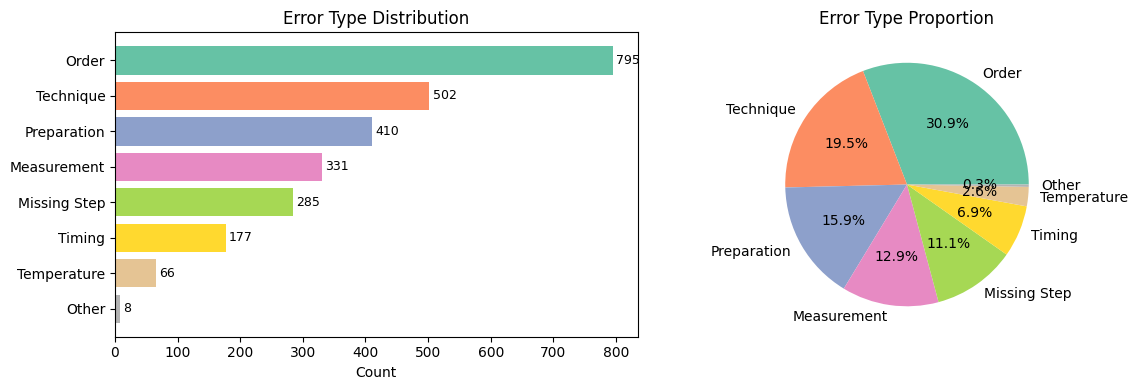

In [9]:
# APPENDIX: Visualization of error distribution
import matplotlib.pyplot as plt
import numpy as np

sorted_errors = sorted(error_type_counts.items(), key=lambda x: -x[1])
labels = [e[0].replace(' Error', '') for e in sorted_errors]
counts = [e[1] for e in sorted_errors]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

# Bar chart
axes[0].barh(labels, counts, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Error Type Distribution')
axes[0].invert_yaxis()
for i, c in enumerate(counts):
    axes[0].text(c + 5, i, str(c), va='center', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Error Type Proportion')

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()